# <span style="color:red"> **LSN - Esercitazione 11**
### <span style="color:green"> 29.05.2025
#### <span style="color:green"> Lucrezia Bioni (13655A)

### <span style="color:blue">**_Keras - Regressione lineare con Neural Network_**

Lo scopo di questa esercitazione è affrontare un problema di regressione su dati rumorosi usando una Rete Neurale (NN). In particolare, si vuole mostrare come la capacità di approssimazione dipenda dalla struttura della NN (numero di layer, neuroni, funzioni di attivazione), perché la predizione risulta complessa in presenza di rumore e quali sono le strategie per migliorare l'accuratezza del modello. L'obiettivo è sviluppare un'intuizione pratica sui compromessi tra sottodattamento (modello troppo semplice), sovradattamento (modello troppo complesso) e generalizzazione (prestazioni su dati mai visti).

**Il Problema della Predizione**
Si consideri un processo probabilistico che genera dati etichettati $(x,y)$. I dati sono prodotti estraendo campioni dall'equazione: $y_i = f(x_i) + \eta_i
$, dove $f(x_i)$ è una funzione fissa (potenzialmente sconosciuta), $\eta_i$ è un rumore gaussiano scorrelato con proprietà: $
  \langle \eta_i \rangle = 0 , \langle \eta_i \eta_j \rangle = \delta_{ij} \sigma
  $. Si chiamino $f(x_i)$ le caratteristiche vere del processo generatore. Per fare predizioni, si è utilizzata una NN con parametri (pesi e bias). Le funzioni che la NN può rappresentare costituiscono la classe di modelli disponibile per approssimare i dati. Per apprendere i parametri della rete, si sono allenati i modelli su un set di dati di training. Si è poi utilizzato un set di dati di validazione per testare le predizioni su dati mai visti, al fine di valutare la capacità di generalizzazione della rete. Si è misurata la performance della rete calcolando l'errore quadratico medio (MSE) tra i valori predetti dalla rete $\{y_j^\mathrm{pred}\}$  e i valori veri $\{y_j\}$:
     $$ MSE = \frac{1}{N_\mathrm{test}}\sum_{j=1}^{N_\mathrm{test}} (y_j^\mathrm{pred}-y_j)^2 $$

## <span style="color:blue">**Esercizio 11.1**

Lo scopo dell'esercizio è effettuare il fit lineare della funzione $f(x)=2x+1$ tramite una rete neurale, e individuare i parametri che consentano di ottenere i migliori risultati.

Innanzitutto, si sono definiti i parametri della funzione lineare ideale di cui si vuole effettuare il fit.

In [220]:
# target parameters of f(x) = m*x + b
m = 2 # slope
b = 1 # intersect

Si è poi generato un set di dati di input che deviano dal comportamento ideale, tramite l'introduzione di rumore:

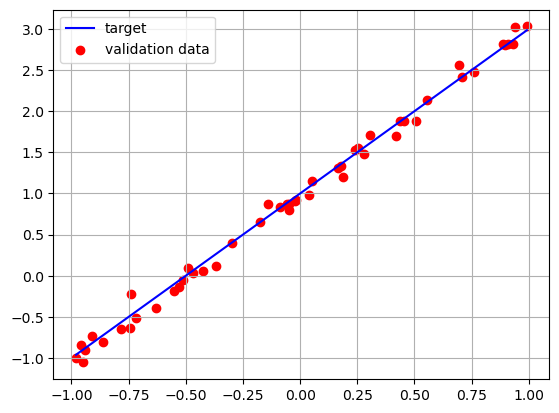

In [221]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 1000)
x_valid = np.random.uniform(-1, 1, 50)
x_valid.sort()
y_target = m * x_valid + b # ideal (target) linear function

sigma = 0.1 # noise standard deviation
y_train = np.random.normal(m * x_train + b, sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(m * x_valid + b, sigma)

# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target', color='b')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

Si è realizzato un modello sequenziale costituito da un singolo neurone:

In [222]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Dense(1, input_shape=(1,)))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse'])

# get a summary of our composed model
model.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_50 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

Dopo aver realizzato il modello, lo si è allenato con un set di coppie di dati (`x_train`, `y_train`), tramite il quale l'ottimizzatore (`stochastic gradient descent`) trova i migliori pesi per minimizzare la funzione di loss costituita dall'errore quadratico medio. Si è osservato che, aumentando il numero di dati di training e di test, è possibile ottenere valori inferiori di funzione di loss. Tuttavia, oltre una certa soglia di ampiezza del dataset (1000), non si ottengono significativi miglioramenti, perciò si è scelta tale soglia come grandezza del dataset. Inoltre, aumentando eccessivamente l'ampiezza del dataset di training, si incorre in overfitting.

In [223]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=30,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.9554 - mse: 0.9554 - val_loss: 0.3981 - val_mse: 0.3981
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3386 - mse: 0.3386 - val_loss: 0.1678 - val_mse: 0.1678
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1392 - mse: 0.1392 - val_loss: 0.0882 - val_mse: 0.0882
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0735 - mse: 0.0735 - val_loss: 0.0541 - val_mse: 0.0541
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0456 - mse: 0.0456 - val_loss: 0.0377 - val_mse: 0.0377
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0312 - mse: 0.0312 - val_loss: 0.0280 - val_mse: 0.0280
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0238 - mse: 0.0238 - val_loss: 0.0219 - val_mse: 0.0219
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0177 - mse: 0.0177 - val_loss: 0.0177 - val_mse: 0.0177
Epoch 9/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0141 - mse: 

Si può verificare la bontà del fit guardando i pesi e i bias, sapendo che $w_1$ rappresenta il coefficiente angolare, e $b$ l'intercetta.

In [224]:
# return weights and biases
model.get_weights()

[array([[1.9949948]], dtype=float32), array([1.0039475], dtype=float32)]

In [225]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0088 - mse: 0.0088

Test loss: 0.008475162088871002
Test accuracy: 0.008475162088871002


In [226]:
# evaluate model with the exact curve
score = model.evaluate(x_valid, y_target, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 3.0273e-05 - mse: 3.0273e-05

Test loss: 2.587158633104991e-05
Test accuracy: 2.587158633104991e-05


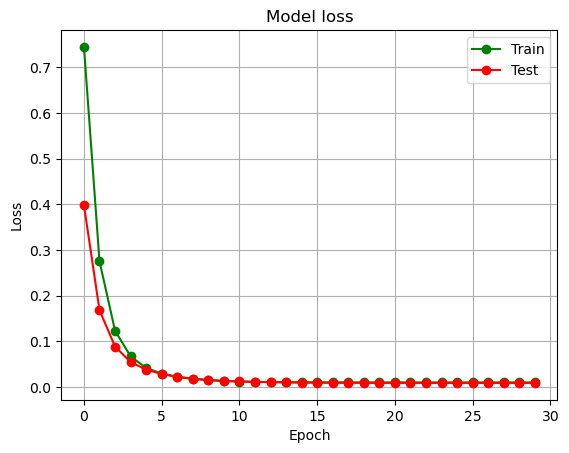

In [227]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], 'go-')
plt.plot(history.history['val_loss'], 'ro-')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid('true')
plt.show()

Osservo che la loss di test scende, fino a stabilizzarsi, e non risale mai: questo suggerisce che non si è incorsi in overfitting, ma che le capacità di generalizzazione della rete sono buone.

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


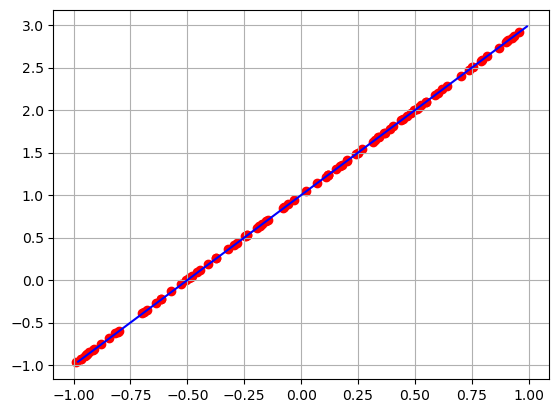

In [228]:
x_predicted = np.random.uniform(-1, 1, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r',label="Model prediction")
plt.plot(x_valid, y_target, color='b',label="Target function")
plt.grid(True)
plt.show()

Nonostante la semplicità della rete neurale, questa mostra ottime capacità predittive. Aggiungere complessità non migliorerebbe i risultati, e potrebbe addirittura portare a overfitting. \
L'introduzione di rumore controllato (con il giusto valore di $\sigma$) si è rivelata la chiave per una buona generalizzazione. Anche se aumenta leggermente la loss, il compromesso è vantaggioso: il modello impara a ignorare il rumore e a catturare meglio i pattern veri nei dati.

## <span style="color:blue">**Esercizio 11.2**

Si è esteso il modello realizzato in precedenza per ottenere un fit del seguente polinomio di ordine 3: $f(x)=4-3x-2x^2+3x^3$, con $x \in [-1,1]$. \
Rispetto al caso precedente, si è ampliato il dataset di training e di test, facendo sempre attenzione a evitare l'overfitting.

In [245]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(-1, 1, 10000)
x_valid = np.random.uniform(-1, 1, 100)
x_valid.sort()
y_target = 4 - 3 *  x_valid - 2 *  x_valid *  x_valid + 3 *  x_valid *  x_valid * x_valid  # ideal (target) linear function

sigma = 0.1 # noise standard deviation
y_train = np.random.normal(4 - 3 * x_train - 2 * x_train * x_train + 3 * x_train * x_train *x_train  , sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(4 - 3 * x_valid - 2 * x_valid * x_valid + 3 * x_valid * x_valid* x_valid , sigma)

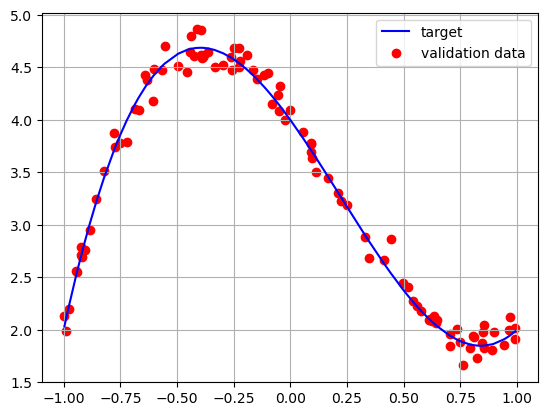

In [246]:
# plot validation and target dataset
import matplotlib.pyplot as plt
plt.plot(x_valid, y_target, label='target', color='b')
plt.scatter(x_valid, y_valid, color='r', label='validation data')
plt.legend()
plt.grid(True)
plt.show()

In [247]:
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model = tf.keras.Sequential()
model.add(Dense(32, input_shape=(1,), activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1,))

# compile the model choosing optimizer, loss and metrics objects
model.compile(optimizer='sgd', loss='mse', metrics=['mse']) 

In [248]:
# get a summary of our composed model
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_57 (Dense)                │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [249]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=50,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.6355 - mse: 1.6355 - val_loss: 0.2900 - val_mse: 0.2900
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1743 - mse: 0.1743 - val_loss: 0.0796 - val_mse: 0.0796
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0519 - mse: 0.0519 - val_loss: 0.0407 - val_mse: 0.0407
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0300 - mse: 0.0300 - val_loss: 0.0276 - val_mse: 0.0276
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0214 - mse: 0.0214 - val_loss: 0.0208 - val_mse: 0.0208
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0167 - mse: 0.0167 - val_loss: 0.0173 - val_mse: 0.0173
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0151 - mse: 0.0151 - val_loss: 0.0163 - val_mse: 0.0163
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0133 - mse: 0.0133 - val_loss: 0.0142 - val_mse: 0.0142
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

In [250]:
# evaluate model
score = model.evaluate(x_valid, y_valid, batch_size=32, verbose=1)

# print performance
print()
print('Test loss:', score[0])
print('Test accuracy:', score[1])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0112 - mse: 0.0112 

Test loss: 0.011187377385795116
Test accuracy: 0.011187377385795116


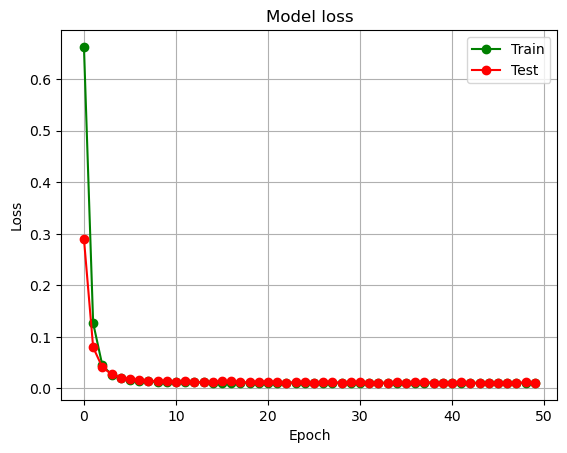

In [251]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], 'go-')
plt.plot(history.history['val_loss'], 'ro-')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid('true')
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


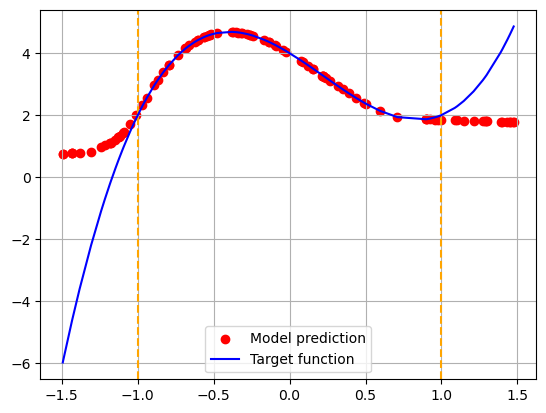

In [252]:
x_predicted = np.random.uniform(-1.5, 1.5, 100)
y_predicted = model.predict(x_predicted)
plt.scatter(x_predicted, y_predicted,color='r', label= "Model prediction")
plt.axvline(1., color = 'orange', linestyle = '--')
plt.axvline(-1., color = 'orange', linestyle = '--')
x_predicted.sort()
y_target_ext = 4 - 3 *  x_predicted - 2 *  x_predicted *  x_predicted + 3 *  x_predicted *  x_predicted * x_predicted 
plt.plot(x_predicted, y_target_ext, color='b',label="Target function")
plt.grid(True)
plt.legend()
plt.show()

Si è complicata la struttura della rete neurale rispetto a quella dell'esercizio precedente: in particolare, si è aumentato il numero di layer, e nei layer non di input è stata aggiunta una funzione di attivazione (relu), che aggiunge non linearità alla rete. Inoltre, si è aumentato il numero di neuroni per layer: si è osservato, infatti, che un numero troppo basso di neuroni non produce buoni risultati. Come ottimizzatore, si è scelto di utilizzare "stochastic gradient descent": con algoritmi più complessi, infatti, come "adam", si è osservato che la rete andava in overfitting.\
Si osserva che la loss di training diminuisce rapidamente nelle prime epoche, mostrando un buon apprendimento iniziale. Dopo la prima fase di rapido miglioramento, la loss continua a scendere in modo più graduale, indicando una convergenza stabile. \
La loss di validazione segue un andamento simile alla training loss, indicando una buona generalizzazione senza evidenti segni di overfitting. La differenza tra loss e val_loss è contenuta, suggerendo che il modello non sta memorizzando i dati di training ma apprendendo pattern significativi.\
L'andamento mostra che 30 epoche potrebbero essere sufficienti per questo modello e dataset. \
Il modello mostra un'ottima capacità di interpolazione all'interno del range di training (linea arancione), dove le previsioni aderiscono bene alla funzione target. Tuttavia, quando si tenta di predire valori al di fuori di questo intervallo, le performance peggiorano significativamente. Questo è un comportamento tipico delle reti neurali, che in genere apprendono bene per interpolazione ma faticano a estrapolare correttamente.

## <span style="color:blue">**Esercizio 11.3**

Si è esteso ulteriormente il modello per effettuare il fit di una semplice funzione trigonometrica 2D $f(x,y) = \sin(x^2+y^2)$ nel range $x \in [-3/2,3/2]$ and $y \in [-3/2,3/2]$. Visto l'aumento significativo di complessità del problema, si è aumentato il numero di dati del set di training e di test.

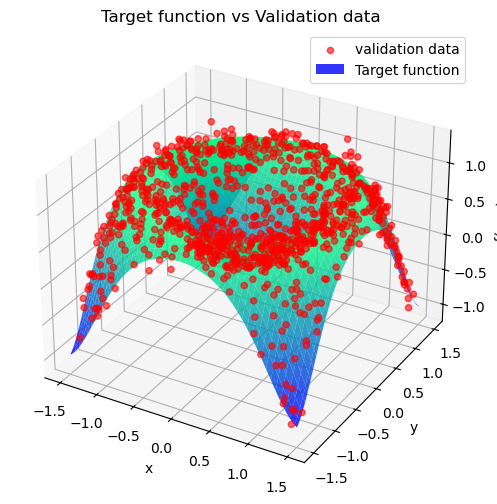

In [311]:
import numpy as np

# generate training inputs
np.random.seed(0)
x_train = np.random.uniform(low=-3./2, high=3./2, size=(10000, 2))
x_valid = np.random.uniform(low=-3./2, high=3./2, size=(1000, 2))
#x_valid.sort
y_target = np.sin(x_valid[:, 0]**2 + x_valid[:, 1]**2)

sigma = 0.1 # noise standard deviation
y_train = np.random.normal(np.sin(x_train[:, 0]**2 + x_train[:, 1]**2), scale=sigma) # actual measures from which we want to guess regression parameters
y_valid = np.random.normal(np.sin(x_valid[:, 0]**2 + x_valid[:, 1]**2), scale=sigma)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Coordinate
x = x_valid[:, 0]
y = x_valid[:, 1]
z_target = y_target
z_valid = y_valid

# Plot 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

#ax.scatter(x, y, z_target,color="blue", label='target', alpha=0.6)
ax.scatter(x, y, z_valid, color='red', label='validation data', alpha=0.6, s=20)

# 1. Crea griglia regolare
x_grid = np.linspace(min(x), max(x), 100)
y_grid = np.linspace(min(y), max(y), 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = np.sin(X**2 + Y**2)
surf = ax.plot_surface(X, Y, Z, cmap='winter', edgecolor='none', alpha=0.8, label="Target function")
ax.legend(['Target surface'])
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Target function vs Validation data')
ax.legend()
plt.show()


In [297]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

# compose the NN model
import tensorflow as tf
from tensorflow import keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras import backend as K
from tensorflow.keras.utils import get_custom_objects

model1 = tf.keras.Sequential()
model1.add(Dense(32, input_shape=(2,), activation='relu'))
model1.add(Dense(16,  activation='relu'))
model1.add(Dense(1,))

# compile the model choosing optimizer, loss and metrics objects
model1.compile(optimizer='adam', loss='mse', metrics=['mse']) 

In [298]:
# get a summary of our composed model
model1.summary()

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_88 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_90 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [299]:
# fit the model using training dataset
# over 10 epochs of 32 batch size each
# report training progress against validation data
history = model1.fit(x=x_train, y=y_train, 
          batch_size=32, epochs=20,
          shuffle=True, # a good idea is to shuffle input before at each epoch
          validation_data=(x_valid, y_valid))

Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2568 - mse: 0.2568 - val_loss: 0.1434 - val_mse: 0.1434
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1332 - mse: 0.1332 - val_loss: 0.1182 - val_mse: 0.1182
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1098 - mse: 0.1098 - val_loss: 0.0934 - val_mse: 0.0934
Epoch 4/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0781 - mse: 0.0781 - val_loss: 0.0518 - val_mse: 0.0518
Epoch 5/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0427 - mse: 0.0427 - val_loss: 0.0258 - val_mse: 0.0258
Epoch 6/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0236 - mse: 0.0236 - val_loss: 0.0174 - val_mse: 0.0174
Epoch 7/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0162 - mse: 0.0162 - val_loss: 0.0137 - val_mse: 0.0137
Epoch 8/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0140 - mse: 0.0140 - val_loss: 0.0119 - val_mse: 0.0119
Epoch 9/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - lo

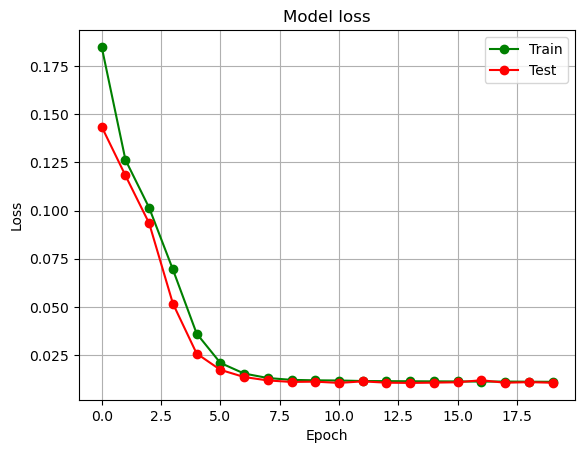

In [300]:
# look into training history
# Plot training & validation loss values
plt.plot(history.history['loss'], 'go-')
plt.plot(history.history['val_loss'], 'ro-')
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='best')
plt.grid('true')
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step


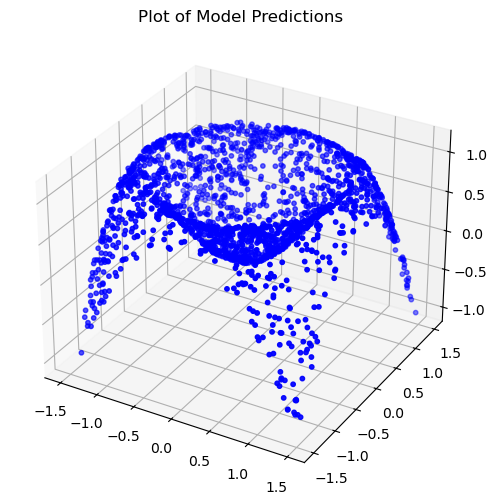

In [312]:
x_predicted = np.random.uniform(-1.5, 1.5,size=(2000, 2))
y_predicted = model1.predict(x_predicted)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(x_predicted[:, 0], x_predicted[:, 1], y_predicted.flatten(), c='blue', s=10)
plt.title("Plot of Model Predictions")

plt.grid(True)
plt.show()


Si è mantenuta una struttura della rete simile ai casi precedenti. Si è tuttavia modificato l'ottimizzatore: al posto di quello basato sull'algoritmo di stochastic gradient descent, si è utilizzato "adam". Si osserva che il fit riesce a riprodurre molto bene l'andamento della funzione nel range in cui si è allenata la rete.